# Web Scraping Quotes (BeautifulSoup)

In [3]:
pip install requests beautifulsoup4 pandas matplotlib

  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached soupsieve-2.8.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
Using cached urllib3-2.6.3-py3-none-any.whl (131 kB)
Using cached beautifulsoup4-4.14.3-py3-none-any.whl (107 kB)
Using cached soupsieve-2.8.3-py3-none-any.whl (37 kB)
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [beautifulsoup4]m [idna]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
url = 'https://quotes.toscrape.com'
response = requests.get(url)
print('Status Code:', response.status_code)

Status Code: 200


In [6]:
soup = BeautifulSoup(response.text, 'html.parser')

In [7]:
quotes = soup.find_all('span', class_='text')
authors = soup.find_all('small', class_='author')

data = []
for i in range(len(quotes)):
    data.append({'Author': authors[i].text, 'Quote': quotes[i].text})

print('Extracted:', len(data))

Extracted: 10


In [8]:
df = pd.DataFrame(data)
df.head()

,Author,Quote
0,Albert Einstein,“The world as we have created it is a process ...
1,J.K. Rowling,"“It is our choices, Harry, that show what we t..."
2,Albert Einstein,“There are only two ways to live your life. On...
3,Jane Austen,"“The person, be it gentleman or lady, who has ..."
4,Marilyn Monroe,"“Imperfection is beauty, madness is genius and..."


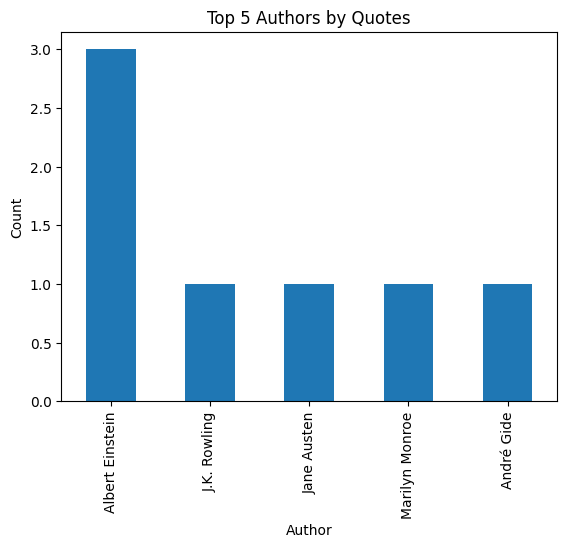

In [9]:
counts = df['Author'].value_counts().head(5)

plt.figure()
counts.plot(kind='bar')
plt.title('Top 5 Authors by Quotes')
plt.xlabel('Author')
plt.ylabel('Count')
plt.show()